----
# <span style="color:#569CD6">Aquatic Ecosystems - lakes section</span>

----
### <span style="color:teal">Damien Bouffard </span>

### <span style="color:teal">2026 </span>
----

# <span style="color:#569CD6">Limnolab</span>



## <span style="color:salmon">Goal</span>


The goal of this LimnoLab is to quantify (i) **the importance of the riverine throughflow heat transport compared to the atmospheric heat fluxes** and (ii) **how this contribution might change with the connection between Lake Schiffenen and Lake Morat**.


Specifically we propose to: 
1. Estimate the heat fluxes (atmospheric and throughflow) over the period 1981 - 2022
2. Estimate the relative importance of the throughflow for the period 1981 - 2022 and possible future connection between Lake Schiffenen and Lake Morat (using period 1981 - 2022 with an increased discharged into Lake Morat)

## <span style="color:salmon">Proposed method</span>

1. Provide a schematic of the problem including heat sources and sinks that illustrate the research question
2. Prepare the dataset (this part is partly provided in this JupyterNotebook)
3. Estimate the atmospheric heat flux (codes are provided)
4. Estimate the river throughflow heat flux (codes are provided)
5. Run the same calculation in case of a future connection between Schiffenen and Morat
6. Evaluate the current contribution of the throughflow on the heat budget
6. Evaluate the future contribution of Lake Schiffenen on the heat budget 
7. Discuss the role of the throughflow. You may consider the change in water residence time between the two scenario


## <span style="color:salmon">Codes</span>
This LimnoLab comes with Python support, complete with a detailed Jupyter Notebook. The code is commented extensively to make it easy for non-expert Python users. You can also convert this code to other programming languages like R or Matlab. Artificial intelligence is also helpful here, assisting with tasks like translating scripts into different languages and explaining or debugging code.

----


# <span style="color:#569CD6">Python scripts</span>


## <span style="color:salmon">Lake Morat properties</span>


In [1]:
Volume_Morat = 0.55 * 1e9  #[m3]
Surf_area = 22.8 * 1e6 #[m2]

# <span style="color:#569CD6">Part 0. Import the libraries</span>


In [2]:
# import the libraries

import pandas as pd
import matplotlib.pyplot as plt
import glob 
import os 
import numpy as np
import datetime

plt.rcParams.update({'font.size': 12})


In [3]:
# Import the heat fluxes scripts as presented during the lecture. 
# You may want to have a look at the scripts

import heat_fluxes_lakes as HF

# <span style="color:#569CD6"> Part 1. Load Meteorological data</span>

Data from the meteorological station from Neuchâtel (MeteoSwiss NEU) and can be found here:

> ./data/Forcing_Morat.dat

**Comments:** 'Forcing_Morat.dat' is an ASCII file (e.g. a text file) that can be opened by all text or data editors (Notepad, TextEdit, Word, Excel etc). For instance, copy the file as 'Forcing_Morat.txt' and open this file with a text editor. The first line is the header and indicates the content of the different columns:
* **Time_[d]**: Time is in day since 01.01.1981. You may check that "0 =  01.01.1981 00:00:00" and "15390.9583 = 2023-02-20 23:00:00"
* **u_[m/s]**: Wind velocity in East direction. Units [m/s]
* **v_[m/s]**: Wind velocity in North direction. Units [m/s]
* **Tair_[°C]**: Air temperature. Units [°C] 
* **sol_[W/m2]**: Net solar radiation. Units  [W/m²]
* **vap_[mbar]**: Water vapor pressure. Units [mbar]
* **cloud_[-]**: Cloud coverage. No units.  0 = cloud free; 1= sky fully covered by clouds
* **rain_[m/hr]**: Precipitation. Units [m/h]


The forcing data are already formated as forcing data for a 1-D lake model Simstrat that will be used in the next LimnoLab (LimnoLab 4)

## <span style="color:salmon">Load forcing data</span>


Note that you may have to adapt the path if not using Renku

We will use Pandas DataFrame to process the data




In [4]:
# load the data
mydir='../data/'
myfile='ForcingMorat.dat'

# create a dataframe
#df = pd.read_csv(os.path.join(mydir, myfile),sep='\s+')
df = pd.read_csv(os.path.join(mydir, myfile), sep=r'\s+')

# print the first lines
df.head()

,Time_[d],u_[m/s],v_[m/s],Tair_[°C],sol_[W/m2],vap_[mbar],cloud_[-],rain_[m/hr]
0,0.0000,5.6783,-0.4968,3.164,0.0,4.2,0.0,0.0
1,0.0417,7.7274,-1.6425,4.364,0.0,2.7,0.0,0.0
2,0.0833,7.7624,-1.9354,3.164,0.0,3.6,0.0,0.0
3,0.1250,6.5683,-1.7600,3.964,0.0,5.1,0.0,0.0
4,0.1667,6.3069,-1.5725,3.864,2.0,5.1,0.0,0.0


Set the index as time

In [5]:
# start of the time serie on 01.01.1981 00:00:00
date_ref=datetime.datetime(1981,1,1)

# create a time vector
df['time'] = pd.to_timedelta(df['Time_[d]'],'D') + date_ref

# set the index as time
df.set_index("time", inplace = True)
df.index = df.index.round('h')

# print the first lines
df.head()

,Time_[d],u_[m/s],v_[m/s],Tair_[°C],sol_[W/m2],vap_[mbar],cloud_[-],rain_[m/hr]
time,,,,,,,,
1981-01-01 00:00:00,0.0000,5.6783,-0.4968,3.164,0.0,4.2,0.0,0.0
1981-01-01 01:00:00,0.0417,7.7274,-1.6425,4.364,0.0,2.7,0.0,0.0
1981-01-01 02:00:00,0.0833,7.7624,-1.9354,3.164,0.0,3.6,0.0,0.0
1981-01-01 03:00:00,0.1250,6.5683,-1.7600,3.964,0.0,5.1,0.0,0.0
1981-01-01 04:00:00,0.1667,6.3069,-1.5725,3.864,2.0,5.1,0.0,0.0


Convert North and East winds into wind speed
and drop unused columns

U_{10} = (u$^2$ + v$^2$)$^{0.5}$


In [6]:
df['U10_[m/s]'] = np.sqrt(df['u_[m/s]']**2 + df['v_[m/s]']**2 )

df.drop('u_[m/s]', axis=1, inplace=True)
df.drop('v_[m/s]', axis=1, inplace=True)
df.drop('Time_[d]', axis=1, inplace=True)

df.head()

,Tair_[°C],sol_[W/m2],vap_[mbar],cloud_[-],rain_[m/hr],U10_[m/s]
time,,,,,,
1981-01-01 00:00:00,3.164,0.0,4.2,0.0,0.0,5.699991
1981-01-01 01:00:00,4.364,0.0,2.7,0.0,0.0,7.900033
1981-01-01 02:00:00,3.164,0.0,3.6,0.0,0.0,8.000039
1981-01-01 03:00:00,3.964,0.0,5.1,0.0,0.0,6.800012
1981-01-01 04:00:00,3.864,2.0,5.1,0.0,0.0,6.499980


## <span style="color:salmon">Select period</span>

Ideally start with a one year period to validate your codes, then the final analysis could be run over the full time window

In [7]:
start_day = '01.01.2010'
end_day = '31.12.2010'

# Convert start / end dates to datetime
start_day = pd.to_datetime(start_day, format='%d.%m.%Y')
end_day = pd.to_datetime(end_day, format='%d.%m.%Y')


## <span style="color:salmon">Display meteorological forcing</span>


* air temperature
* wind speed
* solar radiation

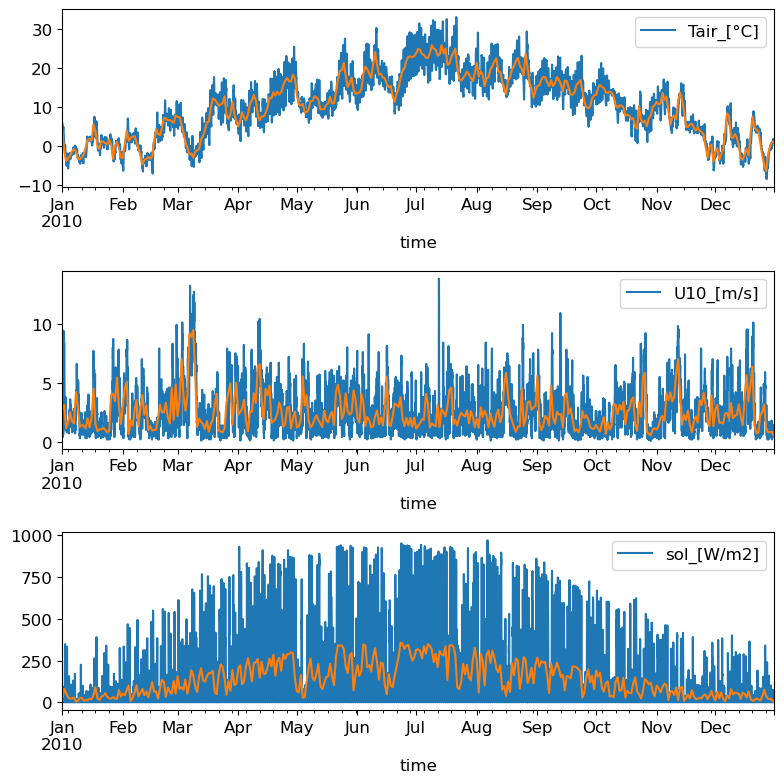

In [8]:
fig, axs = plt.subplots(3, figsize=(8, 8))

df.loc[start_day : end_day]['Tair_[°C]'].plot(ax=axs[0])
df.loc[start_day : end_day]['Tair_[°C]'].resample('D').mean().plot(ax=axs[0],label='_nolegend_')
axs[0].legend()
         
df.loc[start_day : end_day]['U10_[m/s]'].plot(ax=axs[1])
df.loc[start_day : end_day]['U10_[m/s]'].resample('D').mean().plot(ax=axs[1],label='_nolegend_')
axs[1].legend()
         
df.loc[start_day : end_day]['sol_[W/m2]'].plot(ax=axs[2])
df.loc[start_day : end_day]['sol_[W/m2]'].resample('D').mean().plot(ax=axs[2],label='_nolegend_')
axs[2].legend()
                                                                    

plt.tight_layout()



Make sure that the figures are consistent with your expectations

# <span style="color:#569CD6"> Part 2. Load Lake Temperature data</span>

The lake temperature data provided here are already the output of a 1D hydrodynamic model (Simstrat):

> ../data/Results/T_out.dat

Cantonal monitoring data can be found here:

> ../data/Temperature_Morat.csv

They can be used to compare with the model but this is not a requirement here.


## <span style="color:salmon"> Load lake temperature data</span>


In [9]:
# load the data
mydir='../data/Results/'
myfile='T_out.dat'
os.path.join(mydir, myfile)

# create a dataframe
df_T = pd.read_csv(os.path.join(mydir, myfile))
df_T.head()

,Datetime,-45.000,-44.000,-43.000,-42.000,-41.000,-40.000,-39.000,-38.000,-37.000,...,-9.000,-8.000,-7.000,-6.000,-5.000,-4.000,-3.000,-2.000,-1.000,-0.000
0,0.00,5.0580,5.0580,5.0580,5.0580,5.0580,5.0618,5.0888,5.1196,5.1504,...,5.0847,5.0753,5.0661,5.0575,5.0458,5.0150,4.9810,4.9526,4.9575,4.9654
1,0.25,5.0931,5.0946,5.0984,5.1040,5.1116,5.1213,5.1332,5.1476,5.1643,...,5.0689,5.0620,5.0551,5.0480,5.0407,5.0332,5.0253,5.0163,5.0046,4.9893
2,0.50,5.1624,5.1629,5.1639,5.1654,5.1671,5.1691,5.1711,5.1731,5.1750,...,5.0625,5.0590,5.0556,5.0523,5.0493,5.0465,5.0439,5.0414,5.0384,5.0345
3,0.75,5.1692,5.1691,5.1688,5.1683,5.1677,5.1669,5.1659,5.1648,5.1634,...,5.0544,5.0498,5.0447,5.0393,5.0332,5.0266,5.0189,5.0096,4.9959,4.9772
4,1.00,5.1552,5.1550,5.1545,5.1538,5.1529,5.1518,5.1506,5.1492,5.1476,...,5.0108,5.0043,4.9982,4.9911,4.9834,4.9749,4.9655,4.9542,4.9384,4.9174


**Description**:

The first column indicates the time in days. 

The following columns indicate the lake temperature at preselected depth, here every 1 m starting from the bottom = -45.000 to the surface = -0.000

Set time as index

In [10]:
start = 0
date_ref=datetime.datetime(1981,1,1+start)
df_T['time'] = pd.to_timedelta(df_T['Datetime'],'D') + date_ref
df_T.set_index("time", inplace = True)
df_T.drop('Datetime', axis=1, inplace=True)
df_T["doy"] = df_T.index.dayofyear

Keep only the surface temperature data

In [11]:
df_Morat = pd.DataFrame(columns=['Temp_[C]'])
df_Morat['Temp_[C]'] = df_T['-0.000']

df_Morat.head()

,Temp_[C]
time,
1981-01-01 00:00:00,4.9654
1981-01-01 06:00:00,4.9893
1981-01-01 12:00:00,5.0345
1981-01-01 18:00:00,4.9772
1981-01-02 00:00:00,4.9174


Plot the surface temperature

<Axes: xlabel='time'>

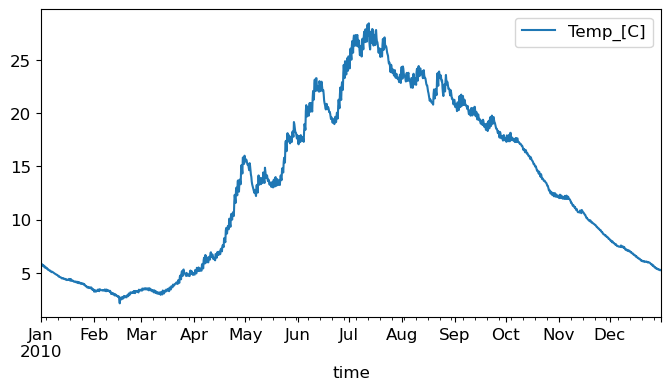

In [12]:
fig, axs = plt.subplots(1, figsize=(8, 4))

df_Morat[start_day : end_day].plot(ax=axs)


# <span style="color:#569CD6"> Part 3. Merge the 2 dataset (meteorological and lake temperature data)</span>


In [13]:
df_all = pd.merge(df, df_Morat, left_index=True, right_index=True)

df_all.head()


,Tair_[°C],sol_[W/m2],vap_[mbar],cloud_[-],rain_[m/hr],U10_[m/s],Temp_[C]
time,,,,,,,
1981-01-01 00:00:00,3.164,0.0,4.2,0.0,0.0000,5.699991,4.9654
1981-01-01 06:00:00,3.264,2.0,5.1,0.0,0.0000,5.399952,4.9893
1981-01-01 12:00:00,3.564,47.0,6.8,1.0,0.0003,4.299954,5.0345
1981-01-01 18:00:00,2.964,2.0,5.2,0.0,0.0000,3.300036,4.9772
1981-01-02 00:00:00,2.564,2.0,4.3,0.0,0.0000,3.699982,4.9174


### Add lake surface temperature to the plot

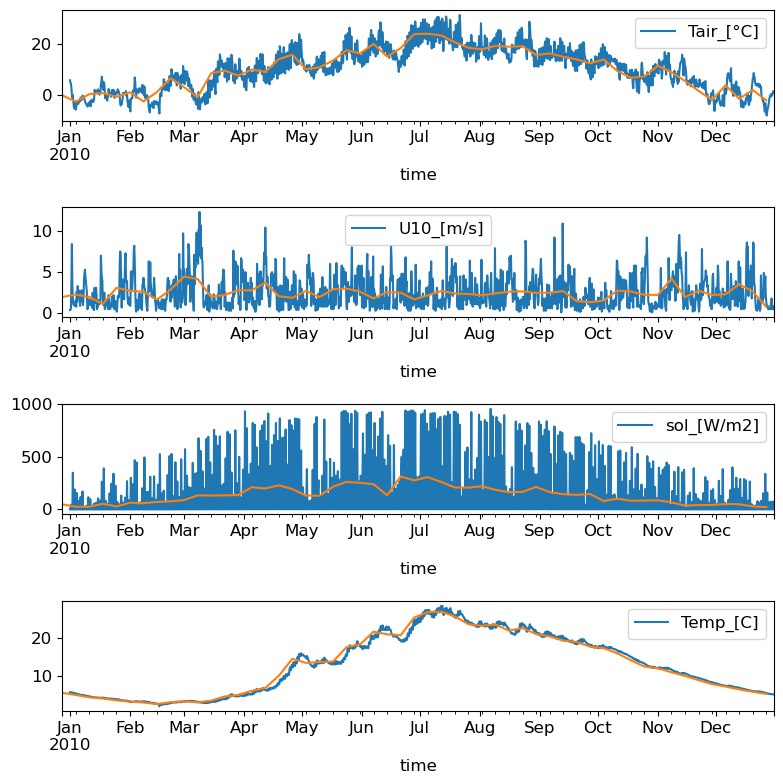

In [14]:
fig, axs = plt.subplots(4, figsize=(8, 8))

df_all.loc[start_day : end_day]['Tair_[°C]'].plot(ax=axs[0])
df_all.loc[start_day : end_day]['Tair_[°C]'].resample('W').mean().plot(ax=axs[0],label='_nolegend_')
axs[0].legend()

df_all.loc[start_day : end_day]['U10_[m/s]'].plot(ax=axs[1])
df_all.loc[start_day : end_day]['U10_[m/s]'].resample('W').mean().plot(ax=axs[1],label='_nolegend_')
axs[1].legend()

df_all.loc[start_day : end_day]['sol_[W/m2]'].plot(ax=axs[2])
df_all.loc[start_day : end_day]['sol_[W/m2]'].resample('W').mean().plot(ax=axs[2],label='_nolegend_')
axs[2].legend()

df_all.loc[start_day : end_day]['Temp_[C]'].plot(ax=axs[3])
df_all.loc[start_day : end_day]['Temp_[C]'].resample('W').mean().plot(ax=axs[3],label='_nolegend_')
axs[3].legend()

plt.tight_layout()


# <span style="color:#569CD6"> Part 4. Heat flux functions</span>

The functions to calculate the different terms of the heat fluxes can be found here
> ../Notebooks/heat_fluxes_lakes.py

### Direct Albedo

The time varying direct albedo, *Adir*, is added to the previous dataframe

In [15]:

t= df_all.copy()
t.reset_index(drop=False, inplace=True)
t['month'] = pd.DatetimeIndex(t['time']).month

Conditions = [
    (t['month']==1 ),
    (t['month']==2),
    (t['month']==3),
    (t['month']==4),
    (t['month']==5),
    (t['month']==6),
    (t['month']==7),
    (t['month']==8),
    (t['month']==9),
    (t['month']==10),
    (t['month']==11),
    (t['month']==12)
]

Categories =  [0.22, 0.161, 0.108, 0.084,0.075, 0.073, 0.074, 0.080, 0.099, 0.144, 0.210, 0.241]


t['Adir'] = np.select(Conditions, Categories)
t.set_index("time", inplace = True)

df_all['Adir'] = t['Adir']

del t


## <span style="color:salmon"> Heat flux calculation</span>


In [16]:
df_all.head()

,Tair_[°C],sol_[W/m2],vap_[mbar],cloud_[-],rain_[m/hr],U10_[m/s],Temp_[C],Adir
time,,,,,,,,
1981-01-01 00:00:00,3.164,0.0,4.2,0.0,0.0000,5.699991,4.9654,0.22
1981-01-01 06:00:00,3.264,2.0,5.1,0.0,0.0000,5.399952,4.9893,0.22
1981-01-01 12:00:00,3.564,47.0,6.8,1.0,0.0003,4.299954,5.0345,0.22
1981-01-01 18:00:00,2.964,2.0,5.2,0.0,0.0000,3.300036,4.9772,0.22
1981-01-02 00:00:00,2.564,2.0,4.3,0.0,0.0000,3.699982,4.9174,0.22


In [17]:
# Short wave absorption

df_all["H_sw"] = HF.SW(df_all["sol_[W/m2]"],df_all["cloud_[-]"],df_all["Adir"] )



In [18]:
# Incoming long wave radiation

Ea = HF.emissivity_(df_all["Tair_[°C]"], df_all["vap_[mbar]"], df_all["cloud_[-]"] )

df_all["H_lw_in"] = HF.LW_in(df_all["Tair_[°C]"], Ea)
                                 


In [19]:
# Outgoing long wave radiation

df_all["H_lw_out"] = HF.LW_out(df_all["Temp_[C]"])


In [20]:
# Latent heat flux

df_all["H_le"] = HF.He(df_all["Tair_[°C]"],df_all["Temp_[C]"], df_all["U10_[m/s]"], df_all["vap_[mbar]"])

In [21]:
# Sensible heat flux
    
df_all["H_c"] = HF.Hc(df_all["Tair_[°C]"],df_all["Temp_[C]"], df_all["U10_[m/s]"])

### Sum of atmospheric heat flux, Hnet 

In [22]:
df_all["H_net_atm"] = df_all['H_sw'] + df_all['H_lw_in'] + df_all['H_lw_out'] + df_all['H_le'] + df_all['H_c']    

### Plot of atmospheric heat fluxes  


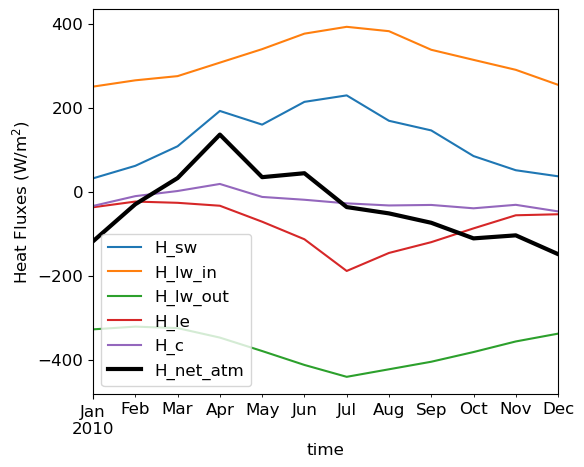

In [23]:
fig, axs = plt.subplots(1, figsize=(6, 5))


df_all.loc[start_day : end_day]['H_sw'].resample('ME').mean().plot(ax=axs)
df_all.loc[start_day : end_day]['H_lw_in'].resample('ME').mean().plot(ax=axs)
df_all.loc[start_day : end_day]['H_lw_out'].resample('ME').mean().plot(ax=axs)
df_all.loc[start_day : end_day]['H_le'].resample('ME').mean().plot(ax=axs)
df_all.loc[start_day : end_day]['H_c'].resample('ME').mean().plot(ax=axs)
df_all.loc[start_day : end_day]['H_net_atm'].resample('ME').mean().plot(ax=axs,lw=3, color ='k')
plt.ylabel('Heat Fluxes (W/m$^2$)')
plt.legend(loc='lower left')


# <span style="color:#569CD6">Part 5 Throughflow</span>


The inflow temperature and discharge data are already formated as input file for the 1D hydrodyanmic model Simstrat

The discharge data of the inflow data can be found here

> ../data/Qin.dat

The Temperature data of the inflow data can be found here

> ../data/Tin.dat

We assume that the discharge of the outflow is equal to the discharge of the inflow

## <span style="color:teal">Load dicharge data</span>

In [24]:

mydir='../data/'
myfile='Qin.dat'
os.path.join(mydir, myfile)

df_Qin = pd.read_csv(os.path.join(mydir, myfile), sep=r'\s+', skiprows=3, names=["Time [d]", "Q_in [m3/s]"])
df_Qin.head()



,Time [d],Q_in [m3/s]
0,0.0417,5.84478
1,0.0833,5.77278
2,0.1250,5.70378
3,0.1667,5.67478
4,0.2083,5.65678


Set time as index

In [25]:
start = 0
date_ref=datetime.datetime(1981,1,1+start)
df_Qin['time'] = pd.to_timedelta(df_Qin['Time [d]'],'D') + date_ref
df_Qin.set_index("time", inplace = True)
df_Qin.drop('Time [d]', axis=1, inplace=True)
df_Qin.head()

,Q_in [m3/s]
time,
1981-01-01 01:00:02.880000000,5.84478
1981-01-01 01:59:57.120000000,5.77278
1981-01-01 03:00:00.000000000,5.70378
1981-01-01 04:00:02.879999999,5.67478
1981-01-01 04:59:57.120000000,5.65678


Rounding the timestepping

In [26]:
df_Qin.index = df_Qin.index.round(freq='h')
df_Qin.head()

,Q_in [m3/s]
time,
1981-01-01 01:00:00,5.84478
1981-01-01 02:00:00,5.77278
1981-01-01 03:00:00,5.70378
1981-01-01 04:00:00,5.67478
1981-01-01 05:00:00,5.65678



## <span style="color:teal">Load inflow temperature data</span>

In [27]:
mydir='../data/'
myfile='Tin.dat'
os.path.join(mydir, myfile)

#df_Tin = pd.read_csv(os.path.join(mydir, myfile), delim_whitespace=True, skiprows=3, names=["Time [d]", "T_in [C]"])
df_Tin = pd.read_csv(os.path.join(mydir, myfile), sep=r'\s+', skiprows=3, names=["Time [d]", "T_in [C]"])
df_Tin.head()


,Time [d],T_in [C]
0,0.0417,0.91599
1,0.0833,0.79624
2,0.1250,0.62658
3,0.1667,0.57669
4,0.2083,0.60667


Set time as index

In [28]:
start = 0
date_ref=datetime.datetime(1981,1,1+start)
df_Tin['time'] = pd.to_timedelta(df_Tin['Time [d]'],'D') + date_ref
df_Tin.set_index("time", inplace = True)
df_Tin.drop('Time [d]', axis=1, inplace=True)
df_Tin.head()

,T_in [C]
time,
1981-01-01 01:00:02.880000000,0.91599
1981-01-01 01:59:57.120000000,0.79624
1981-01-01 03:00:00.000000000,0.62658
1981-01-01 04:00:02.879999999,0.57669
1981-01-01 04:59:57.120000000,0.60667


Rounding the timestepping

In [29]:
df_Tin.index = df_Tin.index.round(freq='h')
df_Tin.head()

,T_in [C]
time,
1981-01-01 01:00:00,0.91599
1981-01-01 02:00:00,0.79624
1981-01-01 03:00:00,0.62658
1981-01-01 04:00:00,0.57669
1981-01-01 05:00:00,0.60667


# <span style="color:#569CD6">Part 6. Merge the discharge dataset with the previous dataset</span>

In [30]:
df_QT = pd.merge(df_Tin, df_Qin, left_index=True, right_index=True)

df_QT.head()


,T_in [C],Q_in [m3/s]
time,,
1981-01-01 01:00:00,0.91599,5.84478
1981-01-01 02:00:00,0.79624,5.77278
1981-01-01 03:00:00,0.62658,5.70378
1981-01-01 04:00:00,0.57669,5.67478
1981-01-01 05:00:00,0.60667,5.65678


In [31]:
data = pd.merge(df_all, df_QT, left_index=True, right_index=True)

data.head()

,Tair_[°C],sol_[W/m2],vap_[mbar],cloud_[-],rain_[m/hr],U10_[m/s],Temp_[C],Adir,H_sw,H_lw_in,H_lw_out,H_le,H_c,H_net_atm,T_in [C],Q_in [m3/s]
time,,,,,,,,,,,,,,,,
1981-01-01 06:00:00,3.264,2.0,5.1,0.0,0.0000,5.399952,4.9893,0.22,1.800,245.660989,-330.311133,-57.684712,-18.299952,-158.834807,0.63664,5.63978
1981-01-01 12:00:00,3.564,47.0,6.8,1.0,0.0003,4.299954,5.0345,0.22,43.898,300.737011,-330.525822,-26.605481,-13.401169,-25.897461,1.22583,5.53278
1981-01-01 18:00:00,2.964,2.0,5.2,0.0,0.0000,3.300036,4.9772,0.22,1.800,245.314112,-330.253679,-41.685098,-15.903661,-140.728326,2.16432,5.56178
1981-01-02 00:00:00,2.564,2.0,4.3,0.0,0.0000,3.699982,4.9174,0.22,1.800,237.412852,-329.969842,-55.837490,-19.977374,-166.571854,2.06937,5.56976
1981-01-02 06:00:00,0.864,0.0,5.9,0.0,0.0005,3.999980,4.8788,0.22,0.000,242.534582,-329.786727,-37.990753,-36.904007,-162.146903,1.72227,5.42176


In [32]:

data["H_f"] = HF.Hf(data["Q_in [m3/s]"],data["T_in [C]"], data["Temp_[C]"], Surf_area)
data.head()

,Tair_[°C],sol_[W/m2],vap_[mbar],cloud_[-],rain_[m/hr],U10_[m/s],Temp_[C],Adir,H_sw,H_lw_in,H_lw_out,H_le,H_c,H_net_atm,T_in [C],Q_in [m3/s],H_f
time,,,,,,,,,,,,,,,,,
1981-01-01 06:00:00,3.264,2.0,5.1,0.0,0.0000,5.399952,4.9893,0.22,1.800,245.660989,-330.311133,-57.684712,-18.299952,-158.834807,0.63664,5.63978,-4.500475
1981-01-01 12:00:00,3.564,47.0,6.8,1.0,0.0003,4.299954,5.0345,0.22,43.898,300.737011,-330.525822,-26.605481,-13.401169,-25.897461,1.22583,5.53278,-3.863298
1981-01-01 18:00:00,2.964,2.0,5.2,0.0,0.0000,3.300036,4.9772,0.22,1.800,245.314112,-330.253679,-41.685098,-15.903661,-140.728326,2.16432,5.56178,-2.868180
1981-01-02 00:00:00,2.564,2.0,4.3,0.0,0.0000,3.699982,4.9174,0.22,1.800,237.412852,-329.969842,-55.837490,-19.977374,-166.571854,2.06937,5.56976,-2.908188
1981-01-02 06:00:00,0.864,0.0,5.9,0.0,0.0005,3.999980,4.8788,0.22,0.000,242.534582,-329.786727,-37.990753,-36.904007,-162.146903,1.72227,5.42176,-3.137557


Text(0, 0.5, 'Heat Fluxes (W/m$^2$)')

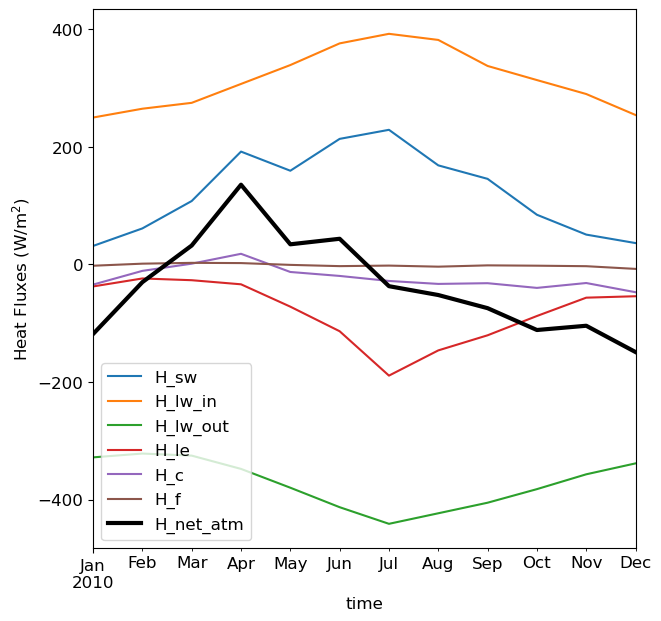

In [33]:
fig, axs = plt.subplots(1, figsize=(7, 7))


data.loc[start_day : end_day]['H_sw'].resample('ME').mean().plot(ax=axs)
data.loc[start_day : end_day]['H_lw_in'].resample('ME').mean().plot(ax=axs)
data.loc[start_day : end_day]['H_lw_out'].resample('ME').mean().plot(ax=axs)
data.loc[start_day : end_day]['H_le'].resample('ME').mean().plot(ax=axs)
data.loc[start_day : end_day]['H_c'].resample('ME').mean().plot(ax=axs)
data.loc[start_day : end_day]['H_f'].resample('ME').mean().plot(ax=axs)
data.loc[start_day : end_day]['H_net_atm'].resample('ME').mean().plot(ax=axs, lw=3, color ='k')
plt.legend(loc='lower left')
plt.ylabel('Heat Fluxes (W/m$^2$)')



# <span style="color:#569CD6">Part 7. Analyse the entire dataset</span>


In [34]:
start_day = '01.01.1981'
end_day = '31.12.2022'

# Convert start / end dates to datetime
start_day = pd.to_datetime(start_day, format='%d.%m.%Y')
end_day = pd.to_datetime(end_day, format='%d.%m.%Y')


data["doy"] = data.index.dayofyear

Text(0, 0.5, 'Heat Fluxes (W/m$^2$)')

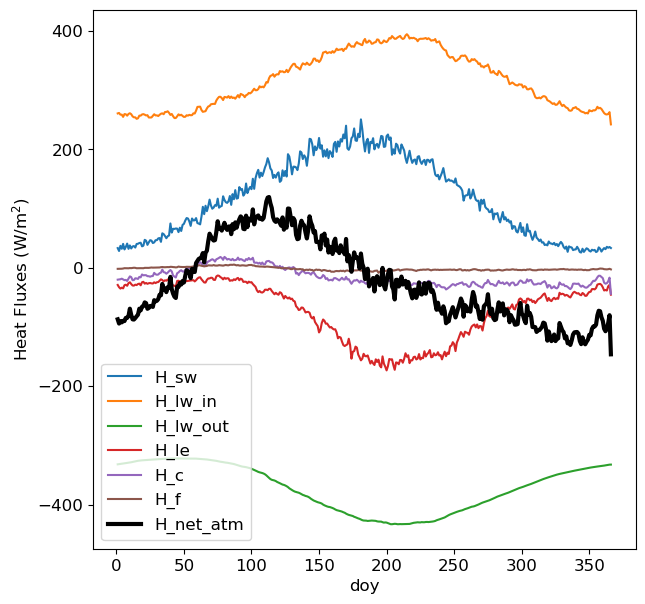

In [35]:
fig, axs = plt.subplots(1, figsize=(7, 7))
data.loc[start_day : end_day].groupby('doy').mean()['H_sw'].plot(ax=axs)
data.loc[start_day : end_day].groupby('doy').mean()['H_lw_in'].plot(ax=axs)
data.loc[start_day : end_day].groupby('doy').mean()['H_lw_out'].plot(ax=axs)
data.loc[start_day : end_day].groupby('doy').mean()['H_le'].plot(ax=axs)
data.loc[start_day : end_day].groupby('doy').mean()['H_c'].plot(ax=axs)
data.loc[start_day : end_day].groupby('doy').mean()['H_f'].plot(ax=axs)
data.loc[start_day : end_day].groupby('doy').mean()['H_net_atm'].plot(ax=axs, lw=3, color ='k')
plt.legend(loc='lower left')
plt.ylabel('Heat Fluxes (W/m$^2$)')





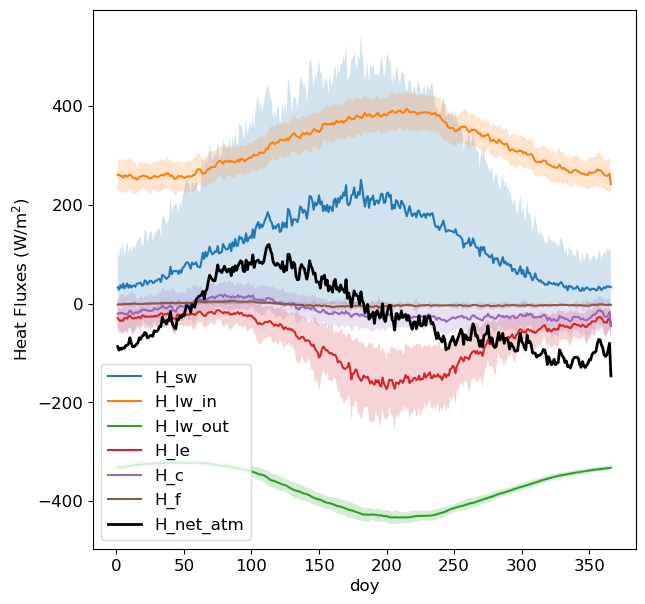

In [36]:
fig, axs = plt.subplots(1, figsize=(7, 7))


# Calculate the mean and standard deviation grouped by 'doy'
grouped_data = data.loc[start_day:end_day].groupby('doy')['H_sw']
mean_values = grouped_data.mean()
std_values = grouped_data.std()
# Plot the mean
mean_values.plot(ax=axs)
# Fill between the mean +/- standard deviation
axs.fill_between(mean_values.index, 0, mean_values + std_values, alpha=0.2,label='_nolegend_')


# Calculate the mean and standard deviation grouped by 'doy'
grouped_data = data.loc[start_day:end_day].groupby('doy')['H_lw_in']
mean_values = grouped_data.mean()
std_values = grouped_data.std()
# Plot the mean
mean_values.plot(ax=axs)
# Fill between the mean +/- standard deviation
axs.fill_between(mean_values.index, mean_values - std_values, mean_values + std_values, alpha=0.2,label='_nolegend_')

# Calculate the mean and standard deviation grouped by 'doy'
grouped_data = data.loc[start_day:end_day].groupby('doy')['H_lw_out']
mean_values = grouped_data.mean()
std_values = grouped_data.std()
# Plot the mean
mean_values.plot(ax=axs)
# Fill between the mean +/- standard deviation
axs.fill_between(mean_values.index, mean_values - std_values, mean_values + std_values, alpha=0.2,label='_nolegend_')

# Calculate the mean and standard deviation grouped by 'doy'
grouped_data = data.loc[start_day:end_day].groupby('doy')['H_le']
mean_values = grouped_data.mean()
std_values = grouped_data.std()
# Plot the mean
mean_values.plot(ax=axs)
# Fill between the mean +/- standard deviation
axs.fill_between(mean_values.index, mean_values - std_values, mean_values + std_values, alpha=0.2,label='_nolegend_')

# Calculate the mean and standard deviation grouped by 'doy'
grouped_data = data.loc[start_day:end_day].groupby('doy')['H_c']
mean_values = grouped_data.mean()
std_values = grouped_data.std()
# Plot the mean
mean_values.plot(ax=axs)
# Fill between the mean +/- standard deviation
axs.fill_between(mean_values.index, mean_values - std_values, mean_values + std_values, alpha=0.2,label='_nolegend_')

# Calculate the mean and standard deviation grouped by 'doy'
grouped_data = data.loc[start_day:end_day].groupby('doy')['H_f']
mean_values = grouped_data.mean()
std_values = grouped_data.std()
# Plot the mean
mean_values.plot(ax=axs)
# Fill between the mean +/- standard deviation
axs.fill_between(mean_values.index, mean_values - std_values, mean_values + std_values, alpha=0.2,label='_nolegend_')

data.loc[start_day : end_day].groupby('doy').mean()['H_net_atm'].plot(ax=axs, lw=2, color ='k')

plt.ylabel('Heat Fluxes (W/m$^2$)')
plt.legend()



# <span style="color:#569CD6"># Part 8. Same analysis but adding the connection between lake Schiffenen and Lake Morat
</span>

**This is now your turn...**


## <span style="color:teal"> Methods</span>

### <span style="color:salmon"> Change throughflow</span>


Hypothesis : the flow is now constant 30 m$^3$/s and the water is taken from the bottom of Lake Schiffenen. We assume first that the bottom temperature of Lake Schiffenen is constant and equal to 5C. You can also test other scenario.

You need to modify:

* The discharge from inflow 'Qin.dat'. The easiest solution is to open this file in a Text Editor or in Excel and to change the discharge to a constant value = 30. Save the file as 'Qin_connection.dat'
* The temperature from inflow 'Tin.dat'. The easiest solution is to open this file in a Text Editor or in Excel and to change the temperature to a constant value = 5. Save the file as 'Tin_connection.dat'

The next step is to run the script above changing:
* myfile='Qin.dat' by myfile='Qin_connection.dat'
* myfile='Tin.dat' by myfile='Tin_connection.dat'


Use the notebook ``change_forcing.ipynb``to modify the forcing

You can copy a new version of this current notebook and estimate the heat fluxes again (running part 1 to 7 with modified inflows)





## <span style="color:teal"> Results and Discussion</span>


* Discuss how the total heat budget will be modified by this connection between Lake Schiffenen and Lake Morat

* Discuss how the lake temperature of Lake Morat will be affected by this connection between Lake Schiffenen and Lake Morat

* Are the conclusion changing if you extract the water at a shallower depth in Lake Schiffenen - for instance 10 m above the bottom at 20 m above the bottom or even at the surface? From a heat budget perspective what should be the ideal depth for extracting the water from Lake Schiffenen? Note that this question of the depth of extracting water in Lake Schiffenen and the depth of the incoming water on Lake Morat should be addressed for every biogeochemical and physical parameter (e.g. change in heat flux, change in tehrmal structure, change in mixing regime, change in the duration of the stratification, optimisation of nutrients loading, avoiding input of hypoxic or anoxic water, discharging water at the density correspondign to the depth of the ouflow etc).Quantify the changes. 

* Provide a convincing conclusion using the schematic that you have prepared at the beginning of this LimnoLab. You may use the paper from Vinna Raman et al. (2018) for your discussion

Raman Vinna, L., Wüest, A., Zappa, M., Fink, G., and Bouffard, D.: Tributaries affect the thermal response of lakes to climate change, Hydrol. Earth Syst. Sci., 22, 31–51, https://doi.org/10.5194/hess-22-31-2018, 2018

Other relevant litterature:

Fink, G., Schmid, M., Wahl, B., Wolf, T., & Wüest, A. (2014). Heat flux modifications related to climate‐induced warming of large European lakes. Water Resources Research, 50(3), 2072-2085.

Piccolroaz, S., Zhu, S., Ladwig, R., Carrea, L., Oliver, S., Piotrowski, A. P., ... & Zhu, D. Z. (2024). Lake water temperature modeling in an Era of climate change: Data sources, models, and future prospects. Reviews of Geophysics, 62(1), e2023RG000816.

Råman Vinnå, L., Wüest, A., & Bouffard, D. (2017). Physical effects of thermal pollution in lakes. Water Resources Research, 53(5), 3968-3987.

Schmid, M., & Read, J. (2022). Heat budget of lakes. Encyclopedia of Inland Waters, second edition, edited by: Mehner, T. and Tockner, K., Elsevier, 467-473.





## Questions

Contact Damien Bouffard damien.bouffard@unil.ch
